# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## Perkenalan Dataset
Pada eksperimen ini, digunakan **Loan Approval Prediction Dataset** yang bersumber dari Kaggle.
Dataset ini berisi data profil nasabah yang mengajukan pinjaman beserta status akhir pengajuannya.

**Tujuan Eksperimen:**
Membangun proses eksplorasi data (EDA) dan preprocessing otomatis untuk memprediksi apakah status pinjaman seseorang akan disetujui (Approved) atau ditolak (Rejected).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [6]:
#Type your code here
# Mengimpor library dasar untuk manipulasi data dan visualisasi
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Menentukan path lokasi dataset mentah
# Menggunakan '../' karena file notebook berada di dalam subfolder /preprocessing
path_raw_data = "/content/loan_approval_dataset.csv"

# Membaca data menggunakan pandas
df_raw = pd.read_csv(path_raw_data)

# Membersihkan spasi pada nama kolom bawaan dataset jika ada
df_raw.columns = df_raw.columns.str.strip()

# Menampilkan 5 baris pertama data untuk memeriksa struktur awal
print(f"[*] Total Baris & Kolom: {df_raw.shape}")
df_raw.head()

[*] Total Baris & Kolom: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
print("[*] Informasi Struktur Dataset:")
df_raw.info()

print("\n[*] Jumlah Nilai Kosong (Missing Values) Per Kolom:")
print(df_raw.isnull().sum())

[*] Informasi Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ K

In [4]:
# Menampilkan ringkasan statistik untuk kolom numerik
print("[*] Statistik Deskriptif Kolom Numerik:")
df_raw.describe()

[*] Statistik Deskriptif Kolom Numerik:


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


/tmp/ipykernel_1873/2916635290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='loan_status', palette='Set2')


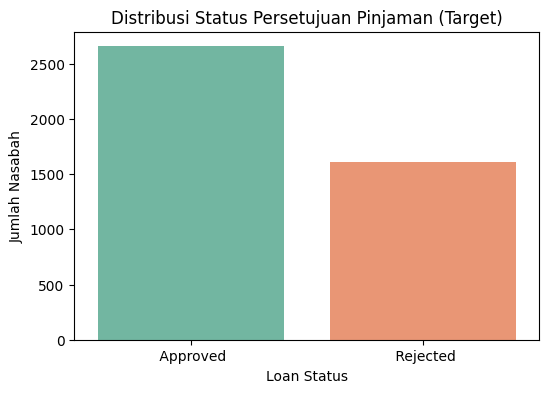

In [5]:
# Membuat plot untuk melihat perbandingan jumlah data target
plt.figure(figsize=(6, 4))
sns.countplot(data=df_raw, x='loan_status', palette='Set2')
plt.title('Distribusi Status Persetujuan Pinjaman (Target)')
plt.xlabel('Loan Status')
plt.ylabel('Jumlah Nasabah')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
# Duplikat data mentah agar data asli tidak rusak
df_manual = df_raw.copy()

# 1. Menghapus kolom 'loan_id' karena tidak memiliki nilai prediktif
if 'loan_id' in df_manual.columns:
    df_manual = df_manual.drop(columns=['loan_id'])
    print("[+] Kolom 'loan_id' berhasil dihapus.")

[+] Kolom 'loan_id' berhasil dihapus.


In [8]:
# 2. Menghapus data duplikat (jika ada)
df_manual = df_manual.drop_duplicates()

In [9]:
# 3. Handling data teks / kategorikal (education & self_employed) dengan LabelEncoder
le = LabelEncoder()
df_manual['education'] = le.fit_transform(df_manual['education'].str.strip())
df_manual['self_employed'] = le.fit_transform(df_manual['self_employed'].str.strip())

In [10]:
# 4. Mengubah target 'loan_status' menjadi biner (1: Approved, 0: Rejected)
df_manual['loan_status'] = df_manual['loan_status'].str.strip().str.lower()
df_manual['loan_status'] = df_manual['loan_status'].apply(lambda x: 1 if x == 'approved' else 0)
print("[+] Encoding data kategorikal dan target selesai.")

[+] Encoding data kategorikal dan target selesai.


In [11]:
# 5. Standarisasi fitur numerik menggunakan StandardScaler
scaler = StandardScaler()
# Ambil semua kolom kecuali target 'loan_status'
fitur_numerik = [col for col in df_manual.columns if col != 'loan_status']
df_manual[fitur_numerik] = scaler.fit_transform(df_manual[fitur_numerik])
print("[+] Standarisasi skala fitur numerik selesai.")

# Menampilkan hasil akhir preprocessing manual
print(f"\n[+] Ukuran data setelah diproses: {df_manual.shape}")
df_manual.head()

[+] Standarisasi skala fitur numerik selesai.

[+] Ukuran data setelah diproses: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,-0.294102,-0.995559,-1.007288,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304,1
1,-1.473548,1.004461,0.992765,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936,0
2,0.295621,-0.995559,-1.007288,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316,0
3,0.295621,-0.995559,-1.007288,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533,0
4,1.475067,1.004461,0.992765,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172,0


In [14]:
# Menentukan path lokasi penyimpanan data bersih
path_output = "loan_data_clean.csv"

# Menyimpan file csv
df_manual.to_csv(path_output, index=False)

print(f"[+] Sukses! Berkas eksperimen manual telah diekspor ke: {path_output}")

[+] Sukses! Berkas eksperimen manual telah diekspor ke: loan_data_clean.csv
